# eHarvest — Demand & Supply Forecasting Training
**Data source:** synthetic `price_observations.csv`  
**Architecture:** one Prophet model per commodity  
**Output artefacts:** `forecast_models.pkl`, `forecast_features.pkl`, `forecast_commodity_list.pkl`, `forecast_training_data.pkl`

## Cell 1 — Imports

In [1]:
import pandas as pd
import numpy as np
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
import joblib
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded.')

c:\Users\munashe\Projects\eharvest-main\eharvest_ai\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


Libraries loaded.


## Cell 2 — Load Data

In [2]:
df = pd.read_csv('price_observations.csv')

print(f'Shape:              {df.shape}')
print(f'Columns:            {df.columns.tolist()}')
print(f'Date range:         {df["date"].min()}  →  {df["date"].max()}')
print(f'Unique commodities: {df["commodity"].nunique()}')
print(f'Unique regions:     {df["region"].nunique()}')
print(f'Null counts:\n{df.isnull().sum()}')

df.head(10)

Shape:              (1000000, 9)
Columns:            ['date', 'commodity', 'category', 'region', 'market', 'price_usd', 'unit', 'price_type', 'data_source']
Date range:         2022-01-01  →  2026-05-22
Unique commodities: 39
Unique regions:     6
Null counts:
date           0
commodity      0
category       0
region         0
market         0
price_usd      0
unit           0
price_type     0
data_source    0
dtype: int64


,date,commodity,category,region,market,price_usd,unit,price_type,data_source
0,2025-12-24,Flour (wheat),misc,Midlands,Kombayi Market (Gweru),2.04,2KG,Retail,synthetic
1,2026-03-03,Spinach (rape),vegetables,Harare,Jambanja Market (Chitungwiza),0.46,Bundle,Retail,synthetic
2,2025-09-07,Rice,cereals and tubers,Midlands,Kwekwe Central Market,0.85,KG,Wholesale,synthetic
3,2025-06-19,Flour (wheat),misc,Bulawayo,Shashe Market,2.03,2KG,Wholesale,synthetic
4,2023-11-25,Cabbages,vegetables,Harare,Mbare Musika,0.88,Head,Wholesale,synthetic
5,2024-05-29,Bananas,fruits,Masvingo,Chitima Market,8.33,Crate,Retail,synthetic
6,2024-11-07,Maize meal,cereals and tubers,Masvingo,Chitima Market,6.19,10KG,Retail,synthetic
7,2024-12-22,Mangoes,fruits,Harare,Lusaka Market (Highfield),4.40,Bucket,Retail,synthetic
8,2024-09-17,Rice,cereals and tubers,Bulawayo,Shashe Market,1.16,KG,Wholesale,synthetic
9,2025-01-04,Millet (finger millet),cereals and tubers,Midlands,Kombayi Market (Gweru),0.72,KG,Retail,synthetic


## Cell 3 — Data Quality Audit
Even though this is synthetic data, always audit before training.

In [3]:
print('=== price_usd statistics ===')
print(df['price_usd'].describe())

print(f'\nZero / null prices: {(df["price_usd"].isnull() | (df["price_usd"] <= 0)).sum()}')

print('\n=== Records per commodity ===')
print(df['commodity'].value_counts())

print('\n=== Records per region ===')
print(df['region'].value_counts())

print('\n=== Price type split ===')
print(df['price_type'].value_counts())

print('\n=== Category split ===')
print(df['category'].value_counts())

=== price_usd statistics ===
count    1000000.000000
mean           2.843909
std            2.695495
min            0.170000
25%            0.680000
50%            1.810000
75%            4.330000
max           15.000000
Name: price_usd, dtype: float64

Zero / null prices: 0

=== Records per commodity ===
commodity
Garlic                     26066
Salt                       25932
Cucumber                   25903
Sorghum                    25895
Onions                     25868
Sugar                      25858
Wheat                      25849
Green pepper               25810
Avocados                   25792
Groundnuts (shelled)       25785
Cooking oil (sunflower)    25769
Soybeans                   25729
Butternuts                 25719
Irish potatoes             25699
Carrots                    25699
Bananas                    25688
Maize                      25678
Millet (finger millet)     25664
Mangoes                    25662
Tomatoes                   25648
Flour (wheat)          

## Cell 4 — Preprocessing

Steps:
1. Parse dates, assign `ds` and `y`
2. Keep **Retail** prices only — mixing retail and wholesale distorts the signal
3. Drop zero / null prices
4. Per-commodity outlier removal using a `for` loop + `pd.concat` (avoids pandas groupby column-dropping bugs)
5. Aggregate daily observations → monthly mean per commodity + region

In [4]:
df['ds'] = pd.to_datetime(df['date'])
df['y']  = df['price_usd']

# Confirm columns are intact before any filtering
print(f'Columns at start: {df.columns.tolist()}')
assert 'commodity' in df.columns, "ERROR: 'commodity' column missing"
assert 'region'    in df.columns, "ERROR: 'region' column missing"

# --- Step 1: Retail prices only ---
before = len(df)
df = df[df['price_type'] == 'Retail'].copy()
print(f'Kept Retail only:   dropped {before - len(df):,} rows. Remaining: {len(df):,}')

# --- Step 2: Drop zero / null prices ---
before = len(df)
df = df[df['y'].notna() & (df['y'] > 0)].copy()
print(f'Dropped bad prices: dropped {before - len(df):,} rows. Remaining: {len(df):,}')

# --- Step 3: Per-commodity outlier removal ---
# Using an explicit for loop + pd.concat — safe across all pandas versions.
# groupby().apply() and groupby().transform() both have version-dependent
# index behaviour that can silently drop the 'commodity' column.
chunks = []
for commodity, group in df.groupby('commodity'):
    Q1    = group['y'].quantile(0.05)
    Q3    = group['y'].quantile(0.95)
    IQR   = Q3 - Q1
    lower = max(0.0, Q1 - 3 * IQR)
    upper = Q3 + 3 * IQR
    chunks.append(group[(group['y'] >= lower) & (group['y'] <= upper)])

before = len(df)
df = pd.concat(chunks, ignore_index=True)
print(f'Removed outliers:   dropped {before - len(df):,} rows. Remaining: {len(df):,}')

# Confirm columns still intact after all filtering
assert 'commodity' in df.columns, "ERROR: 'commodity' lost after filtering"
assert 'region'    in df.columns, "ERROR: 'region' lost after filtering"

# --- Step 4: Aggregate daily → monthly mean per commodity + region ---
# Prophet needs one row per time period — averaging across all markets in a region
df['ds_month'] = df['ds'].dt.to_period('M').dt.to_timestamp()
df_agg = (
    df.groupby(['ds_month', 'commodity', 'region'])['y']
    .mean()
    .reset_index()
    .rename(columns={'ds_month': 'ds'})
)

print(f'\nAggregated shape:   {df_agg.shape}')
print(f'Unique commodities: {df_agg["commodity"].nunique()}')
print(f'Unique regions:     {df_agg["region"].nunique()}')
print(f'Date range:         {df_agg["ds"].min()}  →  {df_agg["ds"].max()}')
df_agg.head()

Columns at start: ['date', 'commodity', 'category', 'region', 'market', 'price_usd', 'unit', 'price_type', 'data_source', 'ds', 'y']
Kept Retail only:   dropped 300,645 rows. Remaining: 699,355
Dropped bad prices: dropped 0 rows. Remaining: 699,355
Removed outliers:   dropped 0 rows. Remaining: 699,355

Aggregated shape:   (12402, 4)
Unique commodities: 39
Unique regions:     6
Date range:         2022-01-01 00:00:00  →  2026-05-01 00:00:00


,ds,commodity,region,y
0,2022-01-01,Avocados,Bulawayo,0.388442
1,2022-01-01,Avocados,Harare,0.388762
2,2022-01-01,Avocados,Manicaland,0.385000
3,2022-01-01,Avocados,Mashonaland West,0.410889
4,2022-01-01,Avocados,Masvingo,0.392414


## Cell 5 — Model Training Helpers

- One Prophet model per commodity
- Region added as a one-hot regressor when multiple regions exist
- `seasonality_mode='multiplicative'` — correct for prices that scale with inflation
- `changepoint_prior_scale=0.1` — moderate trend flexibility

In [5]:
def build_training_frame(commodity_name, df_agg):
    """
    Build the Prophet-ready DataFrame for a single commodity.
    Returns (df_prophet, region_cols).
    """
    subset = df_agg[df_agg['commodity'] == commodity_name].copy()
    has_multiple_regions = subset['region'].nunique() > 1

    if has_multiple_regions:
        region_dummies = pd.get_dummies(subset['region'], prefix='region').astype(int)
        region_cols    = region_dummies.columns.tolist()
        df_prophet     = pd.concat(
            [subset[['ds', 'y']].reset_index(drop=True),
             region_dummies.reset_index(drop=True)],
            axis=1
        )
    else:
        region_cols = []
        df_prophet  = subset[['ds', 'y']].copy()

    return df_prophet, region_cols


def train_commodity_model(commodity_name, df_agg, min_samples=24):
    """
    Train a Prophet model for one commodity.

    Returns:
        model       — fitted Prophet model (None if skipped)
        region_cols — list of regressor column names used
        df_prophet  — training DataFrame (needed for cross-validation)
    """
    df_prophet, region_cols = build_training_frame(commodity_name, df_agg)

    if len(df_prophet) < min_samples:
        print(f'  ⚠  Skipping "{commodity_name}" — {len(df_prophet)} samples < {min_samples} minimum')
        return None, None, None

    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        seasonality_mode='multiplicative',
        changepoint_prior_scale=0.1,
    )

    for col in region_cols:
        model.add_regressor(col)

    model.fit(df_prophet)
    return model, region_cols, df_prophet


print('Training helpers defined.')

Training helpers defined.


## Cell 6 — Train All Commodity Models

In [6]:
models        = {}   # commodity → fitted Prophet model
feature_cols  = {}   # commodity → list of region regressor column names
training_data = {}   # commodity → training DataFrame
skipped       = []

commodities = sorted(df_agg['commodity'].unique())
print(f'Training models for {len(commodities)} commodities...\n')

for i, commodity in enumerate(commodities, 1):
    print(f'[{i:>3}/{len(commodities)}] {commodity}')
    model, cols, df_train = train_commodity_model(commodity, df_agg)

    if model is not None:
        models[commodity]        = model
        feature_cols[commodity]  = cols
        training_data[commodity] = df_train
    else:
        skipped.append(commodity)

print(f'\n✅ Trained:  {len(models)} models')
print(f'⚠  Skipped:  {len(skipped)} — {skipped}')

Training models for 39 commodities...

[  1/39] Avocados


13:08:22 - cmdstanpy - INFO - Chain [1] start processing
13:08:23 - cmdstanpy - INFO - Chain [1] done processing
13:08:23 - cmdstanpy - INFO - Chain [1] start processing
13:08:23 - cmdstanpy - INFO - Chain [1] done processing


[  2/39] Bananas


13:08:23 - cmdstanpy - INFO - Chain [1] start processing
13:08:23 - cmdstanpy - INFO - Chain [1] done processing


[  3/39] Barley


...

[ 35/39] Spinach (rape)
[ 36/39] Sugar


13:08:29 - cmdstanpy - INFO - Chain [1] start processing
13:08:29 - cmdstanpy - INFO - Chain [1] done processing
13:08:30 - cmdstanpy - INFO - Chain [1] start processing
13:08:30 - cmdstanpy - INFO - Chain [1] done processing


[ 37/39] Sweet potatoes
[ 38/39] Tomatoes


13:08:30 - cmdstanpy - INFO - Chain [1] start processing
13:08:30 - cmdstanpy - INFO - Chain [1] done processing
13:08:30 - cmdstanpy - INFO - Chain [1] start processing
13:08:30 - cmdstanpy - INFO - Chain [1] done processing


[ 39/39] Wheat

✅ Trained:  39 models
⚠  Skipped:  0 — []


## Cell 7 — Cross-Validation & Accuracy Metrics

Run on key commodities first. Once satisfied, set `cv_all = True` to validate every model (slow).

In [7]:
# Set cv_all = True to validate every trained model (takes several minutes)
cv_all = False

KEY_COMMODITIES = [
    'Maize', 'Maize meal (roller)', 'Beans (sugar)', 'Groundnuts (shelled)',
    'Tomatoes', 'Onions', 'Carrots', 'Cabbage', 'Irish potatoes',
    'Oil (vegetable)', 'Beef', 'Fish (kapenta)', 'Salt', 'Sugar',
]

cv_targets = list(models.keys()) if cv_all else [
    c for c in KEY_COMMODITIES if c in models
]

cv_results = {}
header = f'{"Commodity":<30}  {"MAPE":>8}  {"RMSE":>8}  {"Assessment":>14}'
print(f'Running CV on {len(cv_targets)} commodities...\n')
print(header)
print('-' * 70)

for commodity in cv_targets:
    td            = training_data[commodity]
    date_range    = (td['ds'].max() - td['ds'].min()).days
    initial_days  = min(730, int(date_range * 0.6))

    if len(td) < 30:
        print(f'{commodity:<30}  {"SKIPPED (< 30 samples)":>34}')
        continue

    try:
        df_cv   = cross_validation(
            models[commodity],
            initial=f'{initial_days} days',
            period='90 days',
            horizon='180 days',
            disable_tqdm=True,
        )
        metrics = performance_metrics(df_cv)
        cv_results[commodity] = metrics

        mape = metrics['mape'].mean()
        rmse = metrics['rmse'].mean()
        assessment = '✅ Good' if mape < 0.15 else ('⚠  Acceptable' if mape < 0.30 else '❌ Poor')

        print(f'{commodity:<30}  {mape:>7.2%}  {rmse:>8.4f}  {assessment:>14}')

    except Exception as e:
        print(f'{commodity:<30}  CV failed: {e}')

print('\nCross-validation complete.')

13:08:43 - cmdstanpy - INFO - Chain [1] start processing
13:08:43 - cmdstanpy - INFO - Chain [1] done processing


Running CV on 12 commodities...

Commodity                           MAPE      RMSE      Assessment
----------------------------------------------------------------------


13:08:43 - cmdstanpy - INFO - Chain [1] start processing
13:08:43 - cmdstanpy - INFO - Chain [1] done processing
13:08:44 - cmdstanpy - INFO - Chain [1] start processing
13:08:44 - cmdstanpy - INFO - Chain [1] done processing
13:08:44 - cmdstanpy - INFO - Chain [1] start processing
13:08:44 - cmdstanpy - INFO - Chain [1] done processing
13:08:44 - cmdstanpy - INFO - Chain [1] start processing
13:08:44 - cmdstanpy - INFO - Chain [1] done processing
13:08:44 - cmdstanpy - INFO - Chain [1] start processing
13:08:44 - cmdstanpy - INFO - Chain [1] done processing
13:08:45 - cmdstanpy - INFO - Chain [1] start processing
13:08:45 - cmdstanpy - INFO - Chain [1] done processing
13:08:45 - cmdstanpy - INFO - Chain [1] start processing
13:08:45 - cmdstanpy - INFO - Chain [1] done processing
13:08:45 - cmdstanpy - INFO - Chain [1] start processing
13:08:45 - cmdstanpy - INFO - Chain [1] done processing


Maize                             2.75%    0.0131          ✅ Good


13:08:45 - cmdstanpy - INFO - Chain [1] start processing
13:08:45 - cmdstanpy - INFO - Chain [1] done processing
13:08:46 - cmdstanpy - INFO - Chain [1] start processing
13:08:46 - cmdstanpy - INFO - Chain [1] done processing
13:08:46 - cmdstanpy - INFO - Chain [1] start processing
13:08:46 - cmdstanpy - INFO - Chain [1] done processing
13:08:46 - cmdstanpy - INFO - Chain [1] start processing
13:08:46 - cmdstanpy - INFO - Chain [1] done processing
13:08:46 - cmdstanpy - INFO - Chain [1] start processing
13:08:46 - cmdstanpy - INFO - Chain [1] done processing
13:08:47 - cmdstanpy - INFO - Chain [1] start processing
13:08:47 - cmdstanpy - INFO - Chain [1] done processing
13:08:47 - cmdstanpy - INFO - Chain [1] start processing
13:08:47 - cmdstanpy - INFO - Chain [1] done processing
13:08:47 - cmdstanpy - INFO - Chain [1] start processing


...

Fish (kapenta)                    2.25%    0.1967          ✅ Good


13:09:05 - cmdstanpy - INFO - Chain [1] start processing
13:09:05 - cmdstanpy - INFO - Chain [1] done processing
13:09:05 - cmdstanpy - INFO - Chain [1] start processing
13:09:05 - cmdstanpy - INFO - Chain [1] done processing
13:09:06 - cmdstanpy - INFO - Chain [1] start processing
13:09:06 - cmdstanpy - INFO - Chain [1] done processing
13:09:06 - cmdstanpy - INFO - Chain [1] start processing
13:09:06 - cmdstanpy - INFO - Chain [1] done processing
13:09:06 - cmdstanpy - INFO - Chain [1] start processing
13:09:06 - cmdstanpy - INFO - Chain [1] done processing
13:09:06 - cmdstanpy - INFO - Chain [1] start processing
13:09:06 - cmdstanpy - INFO - Chain [1] done processing
13:09:07 - cmdstanpy - INFO - Chain [1] start processing
13:09:07 - cmdstanpy - INFO - Chain [1] done processing
13:09:07 - cmdstanpy - INFO - Chain [1] start processing
13:09:07 - cmdstanpy - INFO - Chain [1] done processing


Salt                              2.52%    0.0196          ✅ Good


13:09:07 - cmdstanpy - INFO - Chain [1] start processing
13:09:07 - cmdstanpy - INFO - Chain [1] done processing
13:09:07 - cmdstanpy - INFO - Chain [1] start processing
13:09:07 - cmdstanpy - INFO - Chain [1] done processing
13:09:08 - cmdstanpy - INFO - Chain [1] start processing
13:09:08 - cmdstanpy - INFO - Chain [1] done processing
13:09:08 - cmdstanpy - INFO - Chain [1] start processing
13:09:08 - cmdstanpy - INFO - Chain [1] done processing
13:09:08 - cmdstanpy - INFO - Chain [1] start processing
13:09:08 - cmdstanpy - INFO - Chain [1] done processing
13:09:08 - cmdstanpy - INFO - Chain [1] start processing
13:09:08 - cmdstanpy - INFO - Chain [1] done processing
13:09:09 - cmdstanpy - INFO - Chain [1] start processing
13:09:09 - cmdstanpy - INFO - Chain [1] done processing


Sugar                             2.15%    0.0804          ✅ Good

Cross-validation complete.


## Cell 8 — Save Artefacts

In [8]:
commodity_list = sorted(list(models.keys()))

joblib.dump(models,          'forecast_models.pkl')
joblib.dump(feature_cols,    'forecast_features.pkl')
joblib.dump(training_data,   'forecast_training_data.pkl')
joblib.dump(commodity_list,  'forecast_commodity_list.pkl')

print('✅ Saved:')
print(f'  forecast_models.pkl           ({len(models)} models)')
print(f'  forecast_features.pkl         (region regressor columns per commodity)')
print(f'  forecast_training_data.pkl    (training data — for retraining / debugging)')
print(f'  forecast_commodity_list.pkl   ({len(commodity_list)} commodity names)')
print(f'\nCommodity list:')
for c in commodity_list:
    print(f'  {c}')

✅ Saved:
  forecast_models.pkl           (39 models)
  forecast_features.pkl         (region regressor columns per commodity)
  forecast_training_data.pkl    (training data — for retraining / debugging)
  forecast_commodity_list.pkl   (39 commodity names)

Commodity list:
  Avocados
  Bananas
  Barley
  Beans (round)
  Beans (sugar)
  Beef
  Butternuts
  Cabbages
  Carrots
  Chicken
  Cooking oil (sunflower)
  Cowpeas
  Cucumber
  Eggs (tray of 30)
  Fish (kapenta)
  Flour (wheat)
  Garlic
  Green pepper
  Groundnuts (shelled)
  Irish potatoes
  Maize
  Maize meal
  Mangoes
  Millet (finger millet)
  Oil (vegetable)
  Okra (derere)
  Onions
  Oranges
  Pigeon peas
  Pumpkin
  Rice
  Salt
  Sorghum
  Soybeans
  Spinach (rape)
  Sugar
  Sweet potatoes
  Tomatoes
  Wheat


## Cell 9 — Inference Helper
Always verify the saved model produces sensible forecasts before deploying.

In [9]:
def forecast_commodity(commodity_name, region=None, periods=12, freq='MS'):
    """
    Generate a price forecast for a given commodity and optional region.

    Args:
        commodity_name (str) : e.g. 'Maize'
        region         (str) : e.g. 'Harare' — optional; national baseline if None
        periods        (int) : number of future months to forecast
        freq           (str) : pandas frequency — 'MS' = month start

    Returns:
        pd.DataFrame: ds, yhat, yhat_lower, yhat_upper, commodity, region
    """
    if commodity_name not in models:
        raise ValueError(
            f"No model for '{commodity_name}'.\n"
            f"Available: {sorted(list(models.keys()))}"
        )
    if not (1 <= periods <= 60):
        raise ValueError('periods must be between 1 and 60.')

    model = models[commodity_name]
    cols  = feature_cols[commodity_name]

    future = model.make_future_dataframe(periods=periods, freq=freq)

    if cols:
        for col in cols:
            future[col] = 0          # national baseline — all regions off

        if region is not None:
            region_col = f'region_{region}'
            if region_col not in cols:
                available = sorted([c.replace('region_', '') for c in cols])
                raise ValueError(
                    f"Region '{region}' not found for '{commodity_name}'.\n"
                    f"Available regions: {available}"
                )
            future[region_col] = 1

    forecast = model.predict(future)

    result = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(periods).copy()
    result[['yhat', 'yhat_lower', 'yhat_upper']] = result[
        ['yhat', 'yhat_lower', 'yhat_upper']
    ].clip(lower=0).round(4)
    result['commodity'] = commodity_name
    result['region']    = region or 'National'

    return result.reset_index(drop=True)


print('forecast_commodity() ready.')

forecast_commodity() ready.


## Cell 10 — Forecast Plots (Visual Sanity Check)

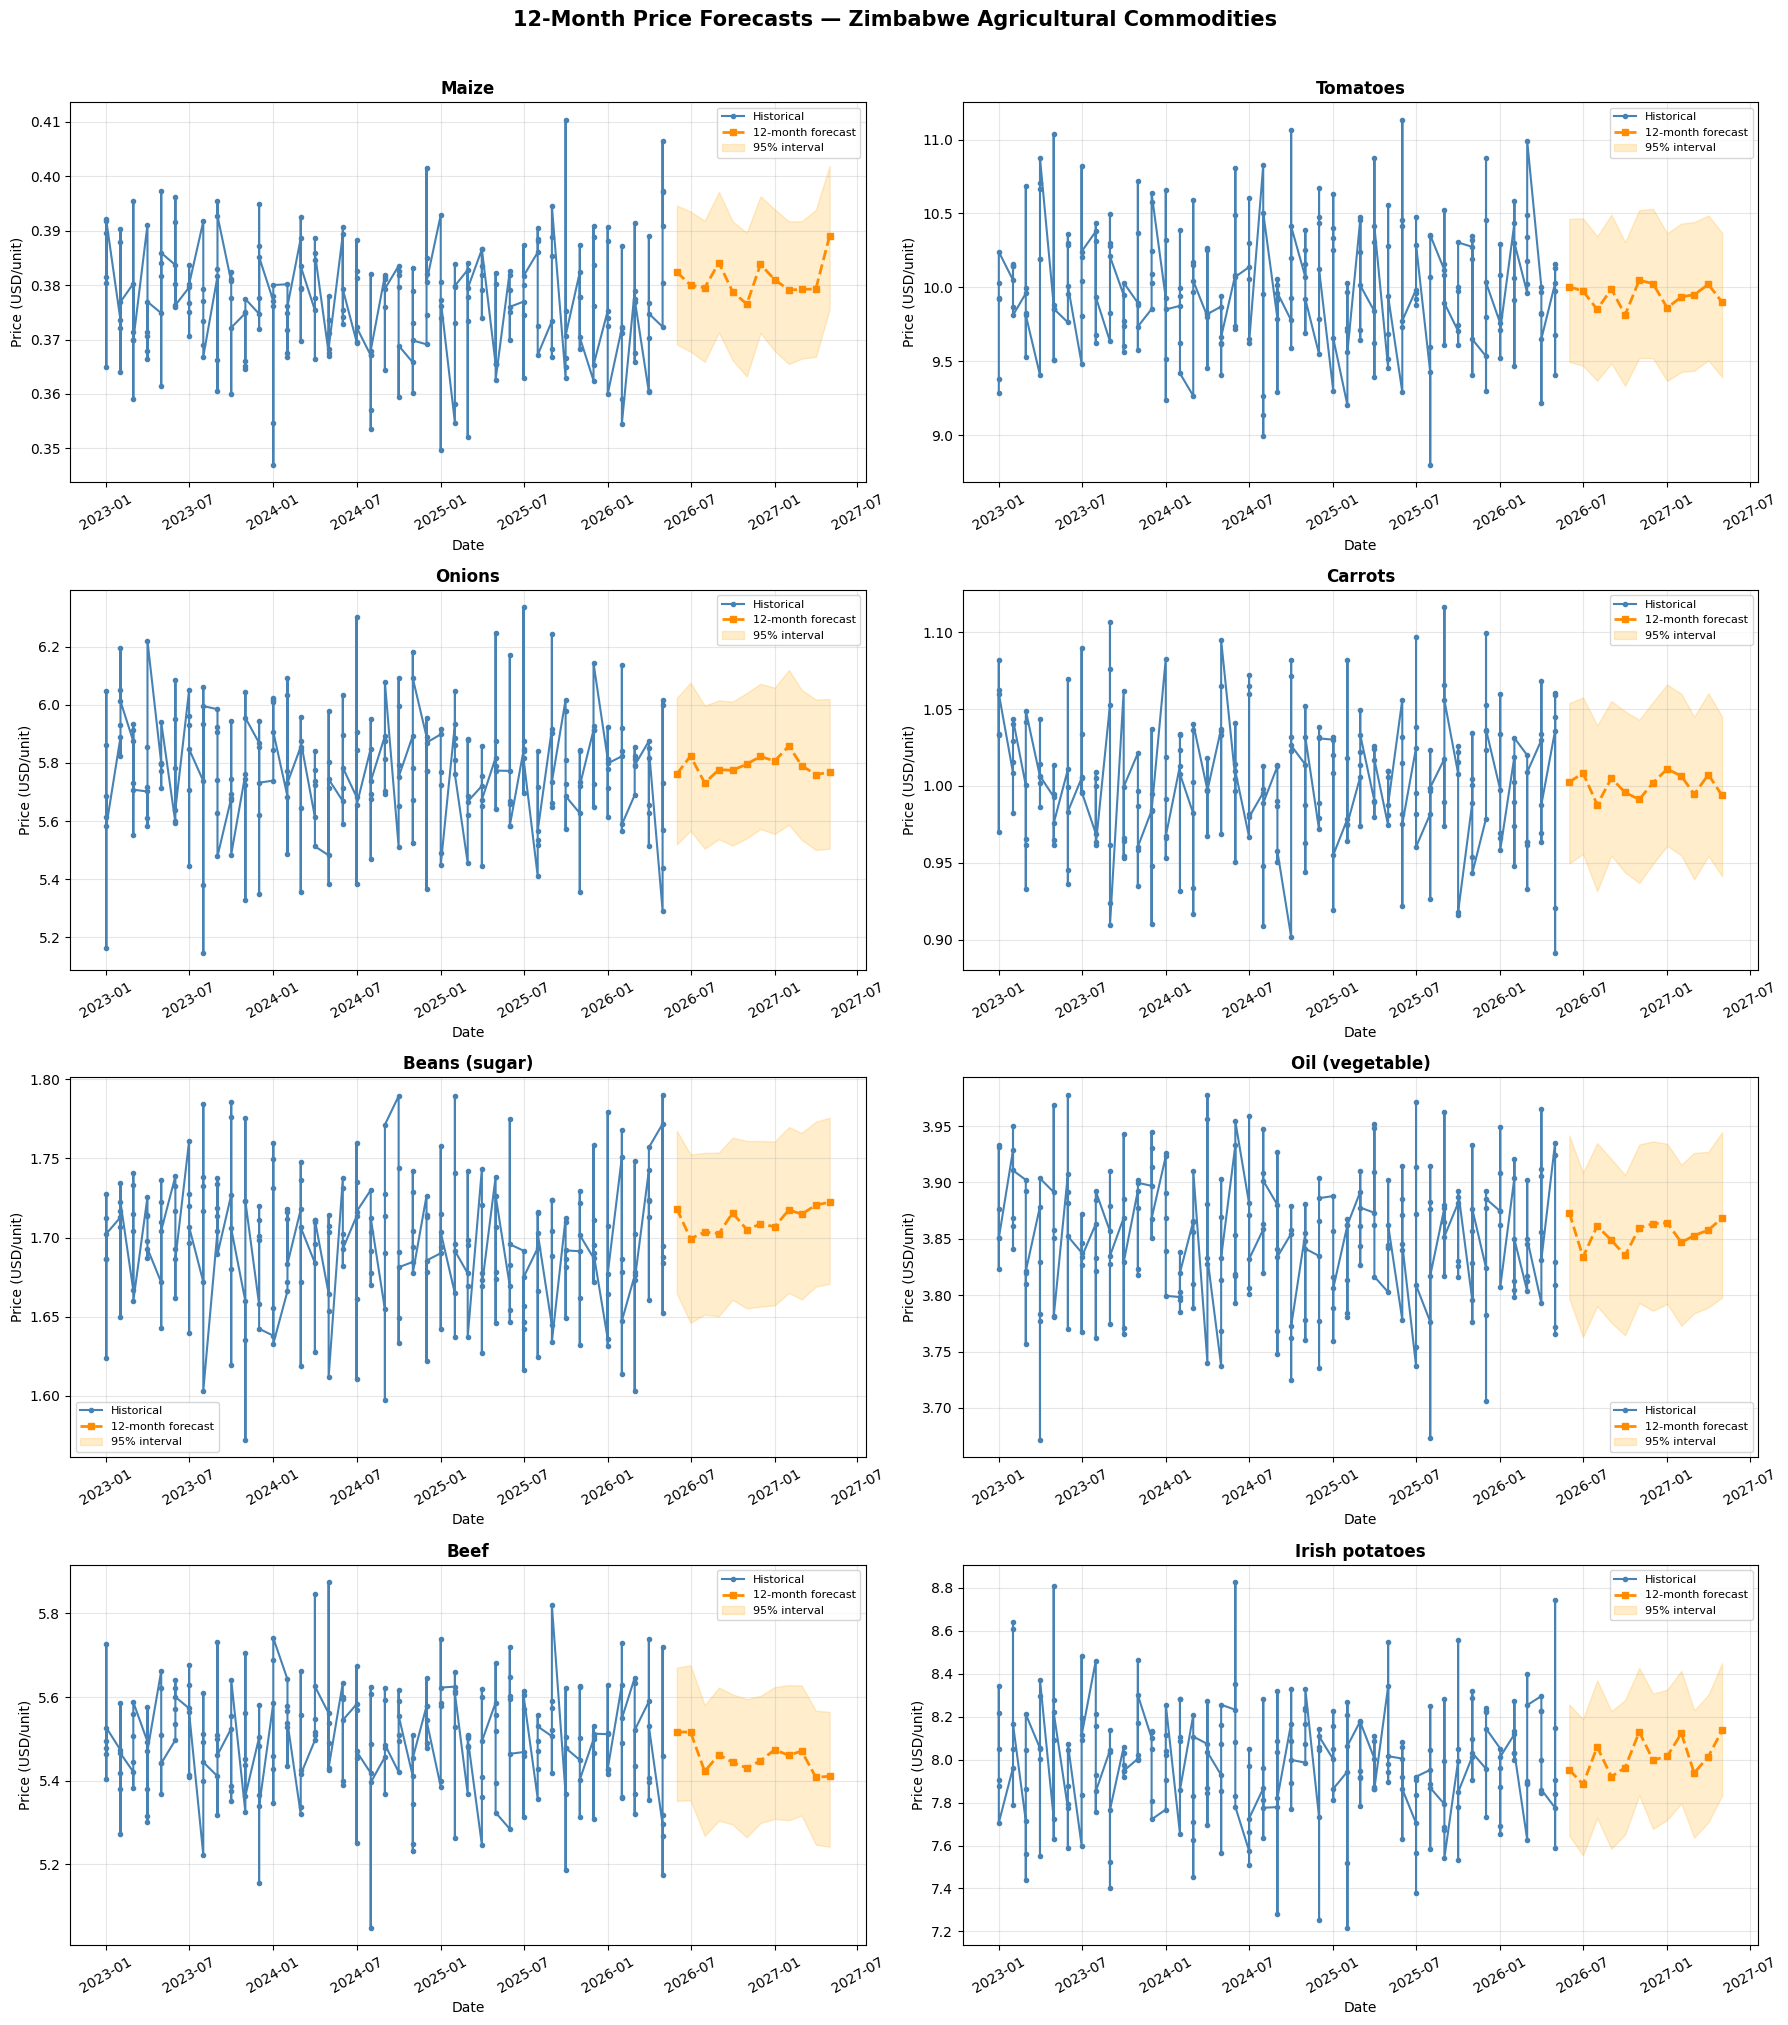

Saved → forecasts.png


In [10]:
PLOT_COMMODITIES = [
    'Maize', 'Tomatoes', 'Onions', 'Carrots',
    'Beans (sugar)', 'Oil (vegetable)', 'Beef', 'Irish potatoes',
]
PLOT_COMMODITIES = [c for c in PLOT_COMMODITIES if c in models]

# Fill remaining slots if any preferred ones weren't trained
for c in commodity_list:
    if c not in PLOT_COMMODITIES and len(PLOT_COMMODITIES) < 8:
        PLOT_COMMODITIES.append(c)

fig, axes = plt.subplots(4, 2, figsize=(18, 20))
axes = axes.flatten()

for i, commodity in enumerate(PLOT_COMMODITIES):
    ax           = axes[i]
    forecast_df  = forecast_commodity(commodity, periods=12)
    hist         = training_data[commodity][['ds', 'y']].copy()
    hist_recent  = hist[hist['ds'] >= pd.Timestamp('2023-01-01')]

    ax.plot(hist_recent['ds'], hist_recent['y'],
            'o-', color='steelblue', label='Historical', markersize=3, linewidth=1.5)
    ax.plot(forecast_df['ds'], forecast_df['yhat'],
            's--', color='darkorange', label='12-month forecast', markersize=5, linewidth=2)
    ax.fill_between(
        forecast_df['ds'],
        forecast_df['yhat_lower'],
        forecast_df['yhat_upper'],
        alpha=0.2, color='orange', label='95% interval'
    )
    ax.set_title(commodity, fontsize=12, fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Price (USD/unit)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('12-Month Price Forecasts — Zimbabwe Agricultural Commodities',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('forecasts.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → forecasts.png')

## Cell 11 — Forecast Table + Error Handling Tests

In [11]:
# Sample forecast — Maize, Harare, 12 months
result = forecast_commodity('Maize', region='Harare', periods=12)
print('12-month forecast — Maize — Harare\n')
print(result.to_string(index=False))

# --- Error handling tests ---
print('\n--- Error handling ---')
try:
    forecast_commodity('Unicorn Crop')
except ValueError as e:
    print(f'Bad commodity caught ✅: {str(e)[:70]}...')

try:
    forecast_commodity('Maize', region='AtlantisProvince')
except ValueError as e:
    print(f'Bad region caught   ✅: {str(e)[:70]}...')

12-month forecast — Maize — Harare

        ds   yhat  yhat_lower  yhat_upper commodity region
2026-06-01 0.3794      0.3662      0.3925     Maize Harare
2026-07-01 0.3770      0.3646      0.3903     Maize Harare
2026-08-01 0.3766      0.3638      0.3891     Maize Harare
2026-09-01 0.3812      0.3692      0.3950     Maize Harare
2026-10-01 0.3759      0.3618      0.3884     Maize Harare
2026-11-01 0.3735      0.3602      0.3860     Maize Harare
2026-12-01 0.3808      0.3685      0.3948     Maize Harare
2027-01-01 0.3780      0.3644      0.3903     Maize Harare
2027-02-01 0.3761      0.3637      0.3884     Maize Harare
2027-03-01 0.3762      0.3635      0.3896     Maize Harare
2027-04-01 0.3764      0.3635      0.3884     Maize Harare
2027-05-01 0.3860      0.3724      0.3996     Maize Harare

--- Error handling ---
Bad commodity caught ✅: No model for 'Unicorn Crop'.
Available: ['Avocados', 'Bananas', 'Barle...
Bad region caught   ✅: Region 'AtlantisProvince' not found for 'Maize'.
Ava

## Cell 12 — End-to-End Inference From Disk
Simulates exactly what the FastAPI service does at startup and at request time.

In [12]:
# Load exactly as app/state.py will
loaded_models        = joblib.load('forecast_models.pkl')
loaded_features      = joblib.load('forecast_features.pkl')
loaded_commodity_list = joblib.load('forecast_commodity_list.pkl')

print(f'Loaded {len(loaded_models)} models from disk.')
print(f'Commodities: {loaded_commodity_list}\n')

def forecast_from_disk(commodity_name, region=None, periods=12):
    """Production-style inference using only disk-loaded artefacts."""
    if commodity_name not in loaded_models:
        raise ValueError(f"'{commodity_name}' not in loaded models.")

    model  = loaded_models[commodity_name]
    cols   = loaded_features[commodity_name]
    future = model.make_future_dataframe(periods=periods, freq='MS')

    if cols:
        for col in cols:
            future[col] = 0
        if region:
            rc = f'region_{region}'
            if rc not in cols:
                raise ValueError(f"Region '{region}' not recognised.")
            future[rc] = 1

    forecast = model.predict(future)
    result   = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(periods).copy()
    result[['yhat', 'yhat_lower', 'yhat_upper']] = (
        result[['yhat', 'yhat_lower', 'yhat_upper']].clip(lower=0).round(4)
    )
    result['commodity'] = commodity_name
    result['region']    = region or 'National'
    return result.reset_index(drop=True)


# Run a quick test — first 3 months
test = forecast_from_disk(loaded_commodity_list[0], periods=3)
print(f'Test forecast — {loaded_commodity_list[0]}:')
print(test.to_string(index=False))
print('\n✅ End-to-end inference from saved artefacts confirmed.')

Loaded 39 models from disk.
Commodities: ['Avocados', 'Bananas', 'Barley', 'Beans (round)', 'Beans (sugar)', 'Beef', 'Butternuts', 'Cabbages', 'Carrots', 'Chicken', 'Cooking oil (sunflower)', 'Cowpeas', 'Cucumber', 'Eggs (tray of 30)', 'Fish (kapenta)', 'Flour (wheat)', 'Garlic', 'Green pepper', 'Groundnuts (shelled)', 'Irish potatoes', 'Maize', 'Maize meal', 'Mangoes', 'Millet (finger millet)', 'Oil (vegetable)', 'Okra (derere)', 'Onions', 'Oranges', 'Pigeon peas', 'Pumpkin', 'Rice', 'Salt', 'Sorghum', 'Soybeans', 'Spinach (rape)', 'Sugar', 'Sweet potatoes', 'Tomatoes', 'Wheat']

Test forecast — Avocados:
        ds   yhat  yhat_lower  yhat_upper commodity   region
2026-06-01 0.3991      0.3792      0.4197  Avocados National
2026-07-01 0.3949      0.3751      0.4144  Avocados National
2026-08-01 0.3970      0.3779      0.4153  Avocados National

✅ End-to-end inference from saved artefacts confirmed.


## Cell 13 — Component Seasonality Plots (Optional Diagnostics)
Shows the learned trend, yearly seasonality, and regressor effects per commodity.  
Useful for verifying the model has picked up the correct seasonal patterns.

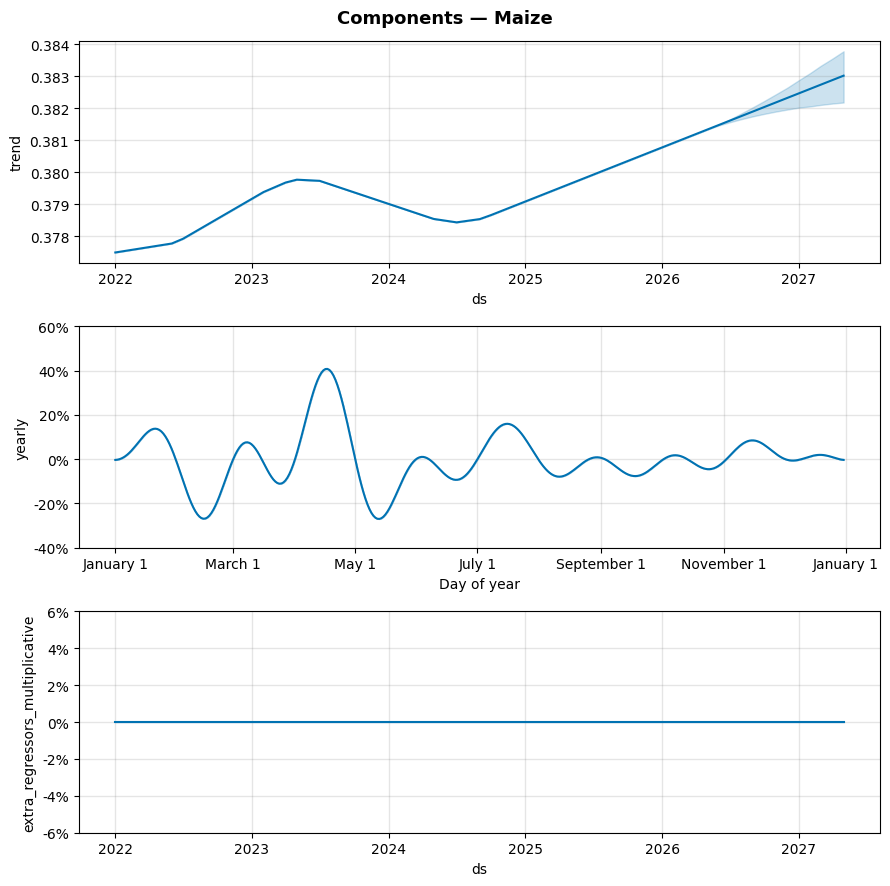

Saved → components_Maize.png


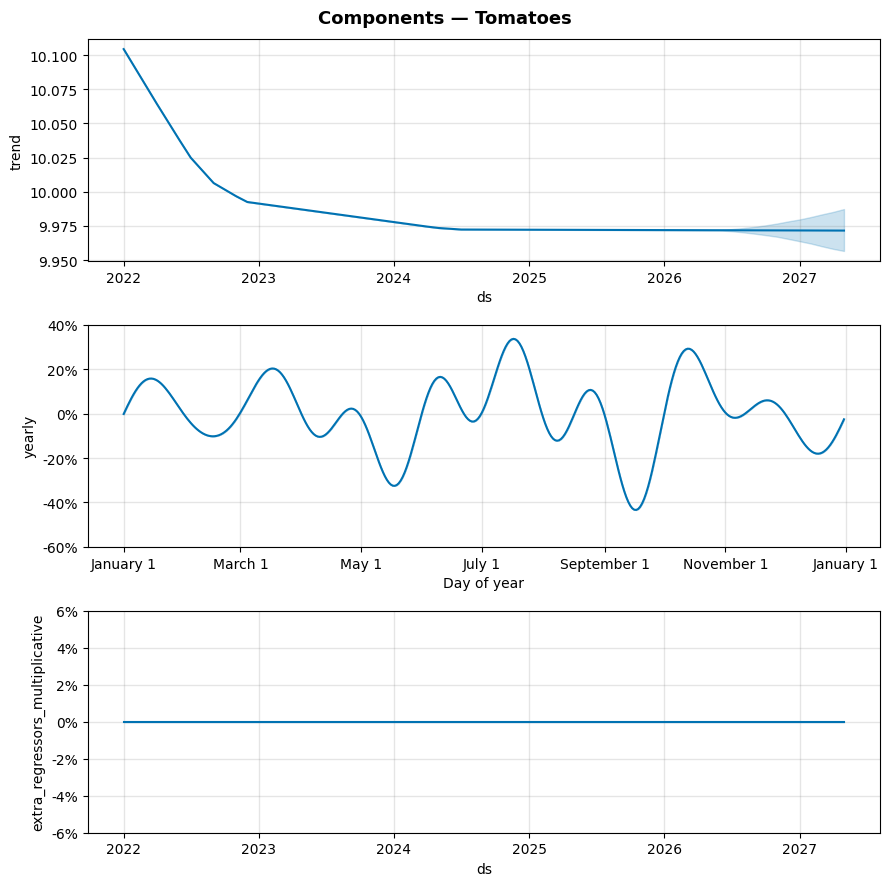

Saved → components_Tomatoes.png


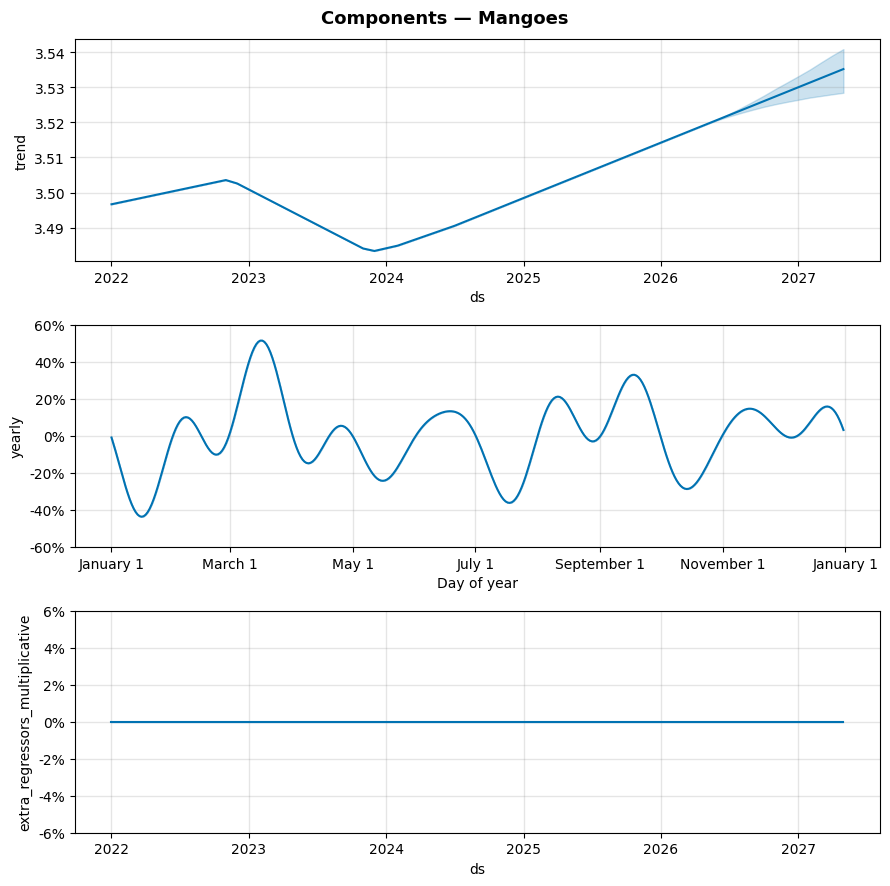

Saved → components_Mangoes.png


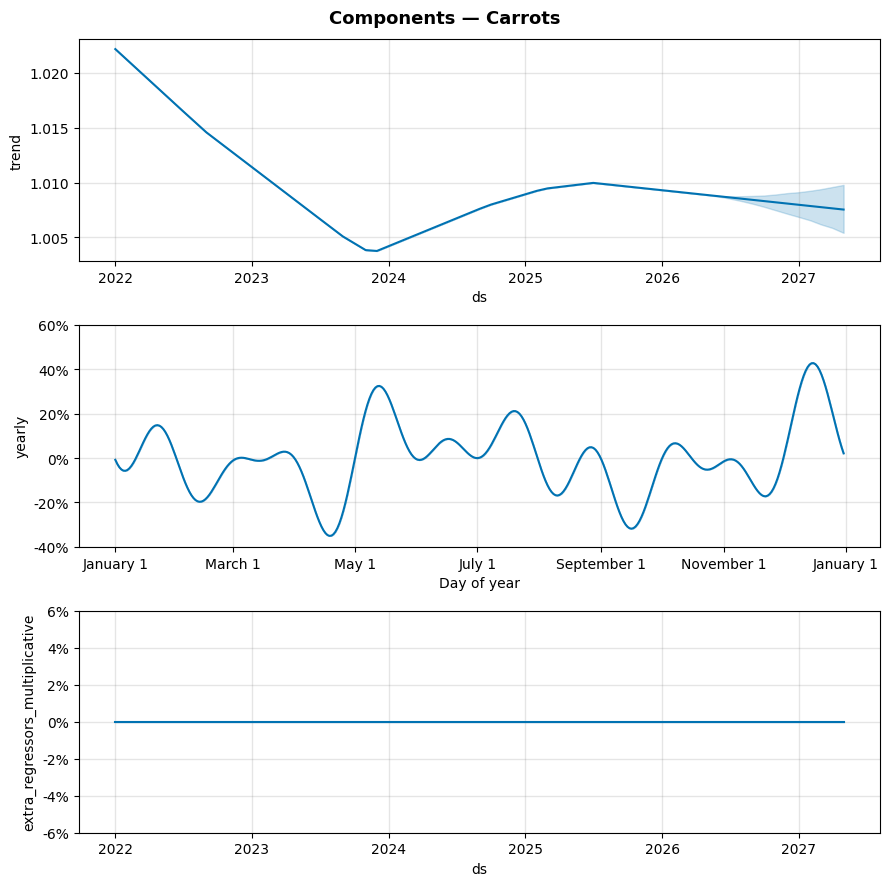

Saved → components_Carrots.png


In [13]:
INSPECT_COMMODITIES = ['Maize', 'Tomatoes', 'Mangoes', 'Carrots']
INSPECT_COMMODITIES = [c for c in INSPECT_COMMODITIES if c in models]

for commodity in INSPECT_COMMODITIES:
    td       = training_data[commodity]
    cols     = feature_cols[commodity]
    future   = models[commodity].make_future_dataframe(periods=12, freq='MS')

    if cols:
        for col in cols:
            future[col] = 0

    forecast = models[commodity].predict(future)
    fig      = models[commodity].plot_components(forecast)
    fig.suptitle(f'Components — {commodity}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'components_{commodity.replace(" ", "_").replace("/","-")}.png',
                dpi=120, bbox_inches='tight')
    plt.show()
    print(f'Saved → components_{commodity}.png')